In [58]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from typing import TypedDict
from dotenv import load_dotenv
load_dotenv()

True

In [59]:
class PromptChainState(TypedDict):
    topic: str
    outline: str
    content: str

In [60]:
model = ChatOpenAI()

In [61]:
def make_outline(state: PromptChainState) -> PromptChainState:
    # code to generate outline from topic
    prompt = f"Provide the outline for topic '{state['topic']}'"
    state['outline'] = model.invoke(prompt).content
    return state

In [62]:
def write_content(state: PromptChainState) -> PromptChainState:
    # code to generate content from outline
    prompt = f"Write content for the following outline: '{state['outline']}'"
    state['content'] = model.invoke(prompt).content
    return state

In [63]:
graph = StateGraph(PromptChainState)

In [64]:
graph.add_node('makeOutline', make_outline)
graph.add_node('writeContent', write_content)

In [65]:
graph.add_edge(START, 'makeOutline')
graph.add_edge('makeOutline', 'writeContent')
graph.add_edge('writeContent', END)

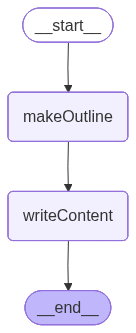

In [66]:
graph.compile()

In [67]:
workflow = graph.compile()
initial_state = {"topic": "The impact of AI on society"}
final_state = workflow.invoke(initial_state)
print(final_state['content'])

I. Introduction

A. AI, or artificial intelligence, has made significant advancements in recent years, leading to its widespread impact on society.
B. The thesis statement will explore the positive and negative impacts of AI on society.

II. Positive impacts of AI on society

A. AI has increased efficiency in various industries, leading to improved productivity and cost savings.
B. In the field of healthcare, AI has helped to develop new medical treatments and improve patient outcomes.
C. AI has enhanced personalization and user experiences, making everyday tasks more convenient and tailored to individual needs.
D. Advancements in education and learning have been made possible through AI technologies, offering new opportunities for personalized and adaptive learning experiences.

III. Negative impacts of AI on society

A. Job displacement and economic implications have been a concern as AI automation replaces human workers in various industries.
B. There are threats to privacy and secu